#**GDG TASK 3**

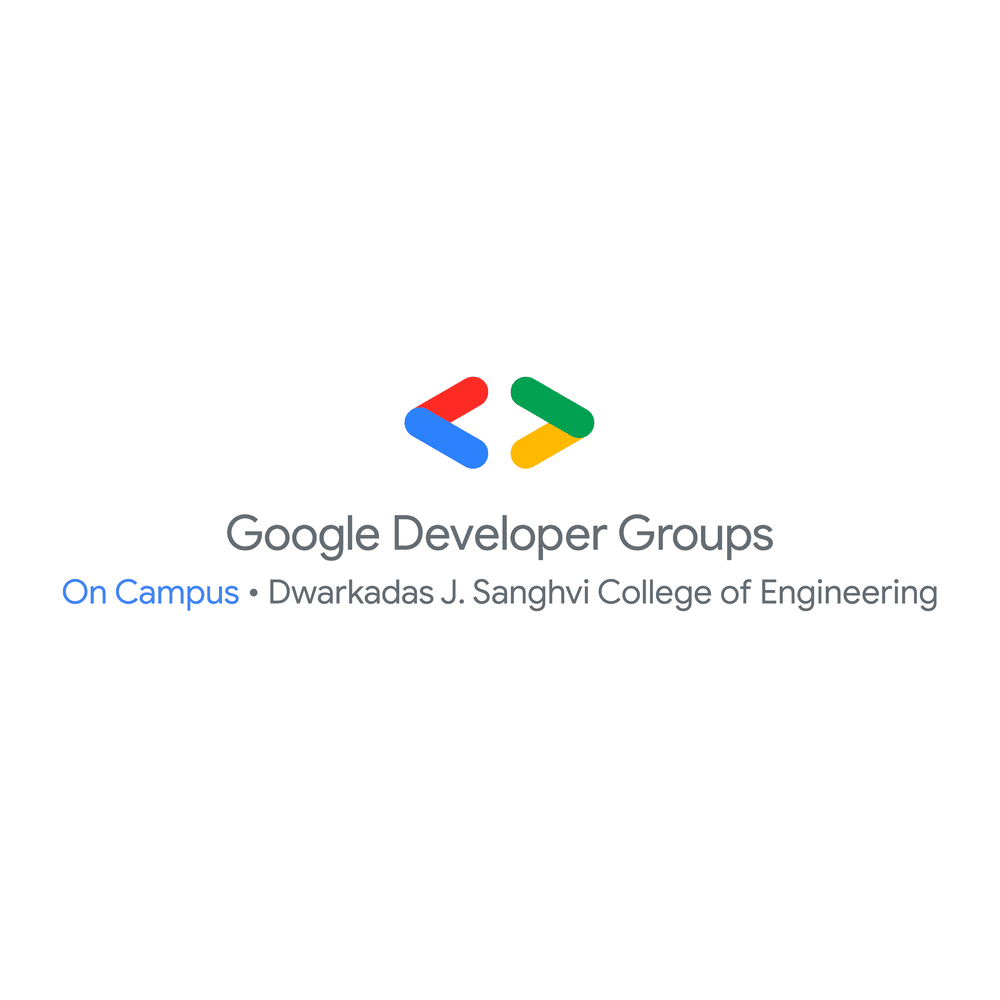

**Unsupervised Learning**

Clustering is an unsupervised learning technique used to group similar data points together. It's widely used in various applications like customer segmentation, anomaly detection, and more. In this task, we'll explore different clustering algorithms and visualize their results.

We will work with the **Samsung Human Activity Recognition dataset**. The data comes from the accelerometers and gyros of Samsung mobile phones, the type of activity of a person with a phone in his pocket is also known - whether he walked, stood, lay, sat or walked up or down the stairs.

We imagine that the type of activity is unknown to us (unlabelled), and we will try to cluster people purely on the basis of available features.

The dataset that will be used can be found here - [DATA](https://drive.google.com/drive/folders/1YiphBhq_SAN5JvCFrorv3pXIvQ22Jtat)

# Importing and Installing all the necessary libaries

In [ ]:
!pip install yellowbrick -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer


from IPython.display import Image,display
from ipywidgets import interact
import os

import warnings
warnings.filterwarnings("ignore")

# Data Loading

Mention the path of dataset, 4 paths for the 4 different txt files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### datasets link :- https://drive.google.com/drive/folders/19nsd8MvooWVsVzkNWxGtbMJheR7kzERt?usp=sharing

In [ ]:
# Mention the path in the strings below
samsung_train_path = '/content/drive/MyDrive/GDG/datasets/samsung_train.txt'
samsung_train_labels_path = '/content/drive/MyDrive/GDG/datasets/samsung_train_labels.txt'
samsung_test_path = '/content/drive/MyDrive/GDG/datasets/samsung_test.txt'
samsung_test_labels_path = '/content/drive/MyDrive/GDG/datasets/samsung_test_labels.txt'

This time we will be using np.loadtxt() for reading our data. Code for the same has been given (do not modify), but we expect you to understand the working of it.

Ref.: https://www.geeksforgeeks.org/numpy-loadtxt-in-python/

In [ ]:
# DO NOT MODIFY
X_train = np.loadtxt(samsung_train_path)
y_train = np.loadtxt(samsung_train_labels_path)#.astype(#fillhere#)

X_test = np.loadtxt(samsung_test_path)
y_test = np.loadtxt(samsung_test_labels_path)#.astype(#fillhere#)

Just to confirm that your data has been loaded properly, execute the below cell. You won't receive any error if everything is correct.

NOTE: If you get an Assertion error, then you probably did something wrong above.

In [ ]:
# Checking dimensions
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

# **Pre-processing**

For clustering, we do not need a target vector, so we'll work with the combination of training and test samples. Merge *X_train* with *X_test*, and *y_train* with *y_test*.

Hint:
1. Merge X_train and X_test into X {use [np.vstack()](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html)}
2. Merge y_train and y_test into y {use [np.hstack()](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html)}

In [ ]:
# code
X=np.vstack((X_train,X_test))
y=np.hstack((y_train,y_test))

Using numpy, print the unique values of the labels of the target class (i.e. "y").

Ref.: https://www.geeksforgeeks.org/python-numpy-np-unique-method/

In [ ]:
# code here
np.unique(y)

array([1., 2., 3., 4., 5., 6.])

Store the size (or number) of unique values of the labels of the target class (i.e. "y") in a variable named n_classes.

In [ ]:
# code
n_classes=len(np.unique(y))

In [ ]:
activities = [
    "walking",
    "going up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "lying down"
]

Here the 6 labels (or classes) correspond to:
- 1 - walking
- 2 - going up the stairs
- 3 - going down the stairs
- 4 - sitting
- 5 - standing
- 6 - lying down

So we wish to create 6 clusters where each cluster can represent one of the above activities.

Scale the sample (i.e. X) using [`StandardScaler()`](https://www.digitalocean.com/community/tutorials/standardscaler-function-in-python)

In [ ]:
# call library
# initialize an instance of StandardScaler()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#code
# use the above instance to fit_transform "X" and assign it into a new variable "X_scaled"
X_scaled = scaler.fit_transform(X)

# **Dimensionality Reduction using PCA**

Ref.: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
# Import PCA from sklearn.decomposition
from sklearn.decomposition import PCA

Reduce the number of dimensions using PCA,

Hints:
1. Initialise instance of PCA and set *n_components* to 0.9 and *random_state* to 17.
2. Fit X_scaled over the PCA instance created
3. Transform X_scaled over the fitted PCA instance and store it in a variable named X_pca.

Theory: https://www.analyticsvidhya.com/blog/2022/07/principal-component-analysis-beginner-friendly/ and https://en.wikipedia.org/wiki/Principal_component_analysis

Theory + Implementation.: https://youtu.be/OFyyWcw2cyM (Jump to timestamp - 13:50 for PCA implementaion)

In [ ]:
# code here
pca=PCA(n_components=0.9,random_state=17)
pca.fit(X_scaled)
X_pca=pca.transform(X_scaled)

Let's check the shape of X_pca.

In [ ]:
# code here
X_pca.shape
# Should print (10299, 65) if everything is correct.

(10299, 65)

Shape of X was (10299, 561) i.e 561 dimensions

Shape of X_pca is (10299, 65) i.e. 65 dimenisons

Hence we have successfully reduced dimensions using PCA.

# K-Means Clustering (Partition-Based Clustering)

K-means clustering is an essential partitioning algorithm used to categorize a dataset into 'k' distinct, non-overlapping clusters. Each data point is assigned to the cluster with the nearest mean or centroid, symbolizing the cluster's center. The primary goal of the algorithm is to minimize the sum of squared distances between data points and their respective cluster centroids.

For an in-depth exploration of K-means clustering, you can refer to this comprehensive article on Analytics Vidhya: [Comprehensive Guide to K-means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/).

For a deeper understanding of the mathematical underpinnings of K-means clustering, Wikipedia is a valuable resource. You can explore the Wikipedia page on K-means clustering for a detailed description: [K-means Clustering Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering). This will help you grasp the mathematical intricacies of the algorithm and its applications in machine learning.

### 2 Dimensional Visualization

In [ ]:
## Perform K-Means clustering with interactive widget
def kmeans_clustering(num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('K-Means Clustering')
    plt.legend()
    plt.show()

low = 2
high = 6
scale = 1

interact(kmeans_clustering, num_clusters=(low,high,scale))

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.kmeans_clustering(num_clusters)>

### 3 Dimensional Visualization

In [ ]:
## Perform K-Means clustering with interactive widget
def kmeans_3d_clustering(num_clusters):
    kmeans_3d = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_3d_labels = kmeans_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Kmeans Clustering (3D)')
    plt.show()

interact(kmeans_3d_clustering, num_clusters=(2, 6, 1))

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.kmeans_3d_clustering(num_clusters)>

### Elbow Point

The "elbow point" is a concept often used in the context of K-means clustering to help determine the optimal number of clusters (k) for a given dataset. It is a graphical method that can assist data analysts and machine learning practitioners in finding an appropriate value for k when applying K-means clustering.

The rationale behind the elbow point method is that as you increase the number of clusters (k), the sum of squared distances will generally decrease because data points will be closer to their respective cluster centroids. However, beyond a certain point, subdividing the data into more clusters doesn't provide significant improvements in reducing the sum of squared distances. The elbow point represents that optimal trade-off between the number of clusters and the compactness of each cluster.

It's important to note that the elbow point method is a heuristic and not a foolproof method for determining the ideal k value. In some cases, the elbow point may not be very pronounced, making it challenging to choose the best k. Additionally, the choice of k should also consider domain knowledge and the specific goals of your analysis.

Elbow Method to determine the number of clusters to be formed:


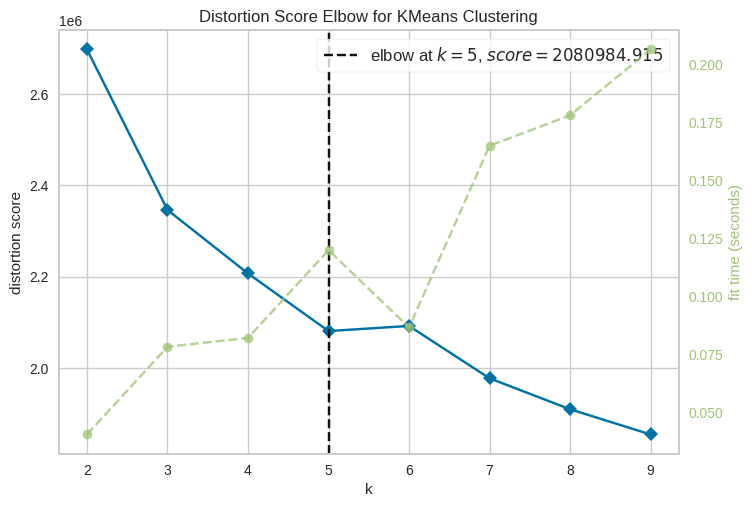

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
print('Elbow Method to determine the number of clusters to be formed:')

Elbow_M = KElbowVisualizer(KMeans(), k=(2, 10))
Elbow_M.fit(X_pca)
Elbow_M.show()

Similar to classification and regression metrics, we have some [clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) to evaluate performance.

We wll explore one of them: [adjusted_rand_index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
# code to compute ARI for our KMeans clusters
ari_score = adjusted_rand_score(y, kmeans_labels)
print(ari_score)

0.30359140125616413


# Agglomerative Clustering

It is a hierarchical clustering algorithm used in unsupervised machine learning and data analysis. It is a "bottom-up" or "agglomerative" approach to clustering, where individual data points are initially treated as their own clusters and then progressively merged into larger clusters based on a similarity or distance metric. The result is a tree-like structure called a dendrogram that represents the hierarchical relationships between clusters.

As always, You can find more detailed information about hierarchical clustering, including agglomerative clustering, in the Wikipedia article on "Hierarchical clustering" at the following link: [Hierarchical Clustering Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering). This is the best resource for hierarchical clustering and it is advisable to go through it twice if possible! :)

### 2 Dimensional Visualization

In [ ]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_clustering(num_clusters):
  agglomerative = AgglomerativeClustering(n_clusters=num_clusters)
  agglomerative_labels = agglomerative.fit_predict(X_pca)

  plt.figure(figsize=(8, 6))
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglomerative_labels, cmap='viridis', edgecolors='k')
  plt.xlabel('Feature 1 (Standardized)')
  plt.ylabel('Feature 2 (Standardized)')
  plt.title('Agglomerative Clustering')
  plt.legend()
  plt.show()

interact(agglomerative_clustering, num_clusters=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.agglomerative_clustering(num_clusters)>

### 3 Dimensional Visualization

In [ ]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_3d_clustering(num_clusters):
    agglomerative_3d = AgglomerativeClustering(n_clusters=num_clusters)
    agglomerative_3d_labels = agglomerative_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agglomerative_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('agglomerative Clustering (3D)')
    plt.show()

interact(agglomerative_3d_clustering, num_clusters=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.agglomerative_3d_clustering(num_clusters)>

In [ ]:
#go through the library of clusteval in order to draw and make dendrograms in your task!

# DBSCAN Clustering

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a popular density-based clustering algorithm in unsupervised machine learning. It is particularly useful for discovering clusters of arbitrary shapes in datasets with varying levels of data density. DBSCAN is known for its ability to handle noise and outliers effectively.

As always, You can find additional information about how DBSCAN clustering works in the following article on Analytics Vidhya:

[How DBSCAN Clustering Works](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/#:~:text=DBSCAN%20is%20a%20density%2Dbased,points%20into%20a%20single%20cluster.)

This article provides a detailed explanation of DBSCAN, including its underlying concepts, the role of epsilon (ε) and minimum points (MinPts), and practical examples of how to use DBSCAN for clustering. It's a valuable resource for gaining a deeper understanding of the algorithm with Wikipedia as the side resource.

### 2 Dimensional Visualization

In [ ]:
# Perform DBSCAN clustering with interactive widget
def dbscan_clustering(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('DBSCAN Clustering')
    plt.legend()
    plt.show()

interact(dbscan_clustering, eps=(0.1,3,1), min_samples=(2,6,1)) # Fill here

interactive(children=(FloatSlider(value=1.1, description='eps', max=3.0, min=0.1, step=1.0), IntSlider(value=4…

<function __main__.dbscan_clustering(eps, min_samples)>

### 3 Dimensional Visualization

In [ ]:
# Perform DBSCAN clustering with interactive widget
def dbscan_3d_clustering(eps, min_samples):
    dbscan_3d = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_3d_labels = dbscan_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=dbscan_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('DBSCAN Clustering (3D)')
    plt.show()
interact(dbscan_3d_clustering, eps=(0.1, 3, 1), min_samples=(2, 6, 1)) # Fill here

interactive(children=(FloatSlider(value=1.1, description='eps', max=3.0, min=0.1, step=1.0), IntSlider(value=4…

<function __main__.dbscan_3d_clustering(eps, min_samples)>

# Mean Shift Clustering

It is a density-based clustering algorithm used in unsupervised machine learning and data analysis. Similar to DBSCAN, Mean Shift is capable of discovering clusters with arbitrary shapes and sizes in a dataset. It is particularly useful for applications where the number of clusters is not known in advance and when clusters have varying densities.

For more hands-on information about the Mean Shift clustering algorithm, you can refer to this tutorial on Analytics India Magazine:

[Hands-On Tutorial on Mean Shift Clustering Algorithm](https://analyticsindiamag.com/hands-on-tutorial-on-mean-shift-clustering-algorithm/)

This tutorial provides practical insights into how to implement and use Mean Shift clustering, making it a valuable resource for those looking to apply this clustering technique to real-world data analysis and machine learning tasks especially in the sector of Image Segmentation.

### 2 Dimensional Visualization

In [ ]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    mean_shift = MeanShift(bandwidth=n_band)
    mean_shift_labels = mean_shift.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mean_shift_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('Mean Shift Clustering')
    plt.legend()
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='n_band', max=6, min=2), Output()), _dom_classes=('widget…

<function __main__.meanshift_clustering(n_band)>

### 3 Dimensional Visualization

In [ ]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    meanshift_3d = MeanShift(bandwidth=n_band)
    meanshift_3d_labels = meanshift_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=meanshift_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Mean Shift Clustering (3D)')
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1))

interactive(children=(IntSlider(value=4, description='n_band', max=6, min=2), Output()), _dom_classes=('widget…

<function __main__.meanshift_clustering(n_band)>

***Congratulations! You have explored various clustering algorithms. Each algorithm has its own advantages and use cases. Remember, choosing the right algorithm and the right number of clusters is crucial. Feel free to experiment with different datasets and parameters to gain a better understanding.***

# **Compulsory**

You can research and create a short blog on the topic of **Spectral Clustering Algortihm and Divisive Clustering**.



## Spectral Clustering Algorithm and Divisive Clustering

Clustering is a fundamental unsupervised learning task aimed at grouping similar data points. While many algorithms exist, two interesting approaches are **Spectral Clustering** and **Divisive Clustering**.

### Spectral Clustering Algorithm

Spectral Clustering is a modern clustering technique with strong ties to graph theory. Unlike traditional methods like K-means, which look for compact, spherical clusters, Spectral Clustering can discover arbitrarily shaped clusters and often performs well when data is not linearly separable.

**How it works:**
1.  **Graph Construction:** The data points are transformed into a similarity graph, where nodes represent data points and edges represent the similarity between them. Higher similarity means a stronger connection.
2.  **Laplacian Matrix:** A special matrix called the Laplacian matrix is derived from this similarity graph.
3.  **Eigenvalue Decomposition:** The eigenvectors corresponding to the smallest eigenvalues of the Laplacian matrix are computed. These eigenvectors provide a low-dimensional embedding of the data that preserves the cluster structure.
4.  **Traditional Clustering:** Finally, a standard clustering algorithm (like K-means) is applied to this new, lower-dimensional representation of the data to identify the clusters.

**Advantages:** Effectively handles non-convex clusters, less sensitive to noise in some cases, and often provides better results on complex datasets.

**Disadvantages:** Computationally more expensive for large datasets due to eigenvalue decomposition, and the choice of similarity graph and parameters can be crucial.

### Divisive Clustering

Divisive Clustering is a top-down hierarchical clustering approach. It starts with all data points in a single, large cluster and recursively divides them into smaller clusters until a stopping criterion is met.

**How it works:**
1.  **Start with One Cluster:** All data points are initially considered as one single cluster.
2.  **Divide:** The algorithm identifies the "loosest" cluster (the one with the largest internal dissimilarity) and splits it into two smaller clusters. This split is often determined by finding the two most dissimilar sub-clusters within the chosen cluster.
3.  **Repeat:** This process of dividing clusters continues until a predefined number of clusters is reached, or until the dissimilarity within each cluster falls below a certain threshold, or each data point forms its own cluster.

**Advantages:** Provides a hierarchical structure which can be informative, doesn't require pre-specifying the number of clusters (though a stopping criterion is needed), and can reveal relationships between clusters at different levels.

**Disadvantages:** Computationally intensive, especially in the initial steps where a large cluster needs to be split optimally, and mistakes made in early divisions can propagate through the hierarchy.


we will be exploring another ML Models like Decision Tree, Random Forest and Naive Bayes. We will also learn hyperparameter tuning using ensemble techniques (Bagging & Boosting) and Decision Tree Pruning.

**This Task has various theory questions to be answered here and there. Don't miss out on those, as they will make you'll conceptually stronger, and give a better understanding.**

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

# Decision Tree Classifier

* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

### separate datset for this task.

Load the titanic dataset in a pandas dataframe (download dataset from https://www.kaggle.com/c/titanic/data and store it in the "Synapse" folder initially created for the interview tasks) Note that you have to download the train and test csv files seperately

<b>Read the train.csv using pandas and show the dataframe</b>

In [ ]:
#code here
df=pd.read_csv("/content/drive/MyDrive/GDG/titanic/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Visualizing hidden Details

* print the name column of the data
* notice that the word after the first comma encapsulates the title of the person (Mr., Mrs, etc)
* extract the title using regular expression (help given below in the code)
* store the title in a new column in the dataframe. Name the column : Title

In [ ]:
print(df['Name'].head())

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print('\nDataFrame with new Title column:')
display(df.head())

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

DataFrame with new Title column:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr



```
# This is formatted as code
```

### Removing unnecessary columns
*   The columns PassengerId and Ticket play no logical role in being related to the survival of a passenger. Hence we will remove them.
*   We will also remove the Name column as we have done feature extraction and obtained titles instead. (test set might have extra titles which are not in the train set. Think about how we would consider them. This however doesn't affect task 1's objective)

In [ ]:
#write code here (PassengerId, Ticket, Name)
df.drop(columns=["PassengerId", "Ticket", "Name"], inplace=True)
display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr


### Nan analysis
*   write code to find the percentage of Nans in each column and visualize it in a tabular format
*   remove any column having more than 50% Nans as they would be of no use

In [ ]:
# likho code and tree null values properly

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2
Title,0


In [ ]:
nan_percentages = df.isnull().sum() / len(df)
col_to_drop = nan_percentages[nan_percentages > 0.5].index

df.drop(columns=col_to_drop, inplace=True)

print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title
0         0       3    male  22.0      1      0   7.2500        S    Mr
1         1       1  female  38.0      1      0  71.2833        C   Mrs
2         1       3  female  26.0      0      0   7.9250        S  Miss
3         1       1  female  35.0      1      0  53.1000        S   Mrs
4         0       3    male  35.0      0      0   8.0500        S    Mr


### Adding features to the dataset
*   Read the kaggle link (titanic dataset) provided above and see what the two columns SibSP and Parch signify
*   Using that create a new column called **Family_members**
*   Fill it with the sum of SibSP and Parch

In [ ]:
#write code here
df["Family_members"]=df["SibSp"]+df["Parch"]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members
0,0,3,male,22.0,1,0,7.2500,S,Mr,1
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0


# **Pre Processing**

In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

display(df.head())
display(df.isnull().sum())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members
0,0,3,male,22.0,1,0,7.2500,S,Mr,1
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0
Family_members,0


In [ ]:
#one hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Family_members,Sex_male,Embarked_Q,Embarked_S,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,0,3,22.0,1,0,7.2500,1,True,False,True,...,False,False,False,False,False,True,False,False,False,False
1,1,1,38.0,1,0,71.2833,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True,...,False,False,True,False,False,False,False,False,False,False
3,1,1,35.0,1,0,53.1000,1,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,0,3,35.0,0,0,8.0500,0,True,False,True,...,False,False,False,False,False,True,False,False,False,False


extract the y label (survived) from the dataframe and store it in a new variable and remove y from original dataframe (x,y split)

In [ ]:
#write code here
X=df.drop(columns=["Survived"])
y=df["Survived"]

<b>Split the data into train and test. (do a split in the ratio 70:30)</b>

In [ ]:
#write code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<b>Now that you have the entire preprocessed and split data, implement the decision tree algorithm from sklearn and fit it to this dataset</b> <br>

In [ ]:
#write code here
from sklearn.tree import DecisionTreeClassifier
tree= DecisionTreeClassifier()
tree.fit(X_train, y_train)

DecisionTreeClassifier()

<b>Print the Model Accuracy</b>

In [ ]:
#write code here
from sklearn.metrics import accuracy_score
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.753731343283582


## Explain: Give a Real life Example where Decision Tree Classifier can be used.

Ans:
A Decision Tree Classifier can be used in **recommendation systems**, like those for streaming services (e.g., Netflix).

**How it works (Netflix example):**

It makes a series of 'yes/no' decisions based on user data:

*   **Q1: User watches comedies?**
    *   **Yes:** Short viewing sessions?
        *   **Yes:** Recommend *short comedies*.
        *   **No:** Recommend *feature comedies*.
    *   **No:** Is it the weekend?
        *   **Yes:** Recommend *binge series*.
        *   **No:** Recommend *popular movies*.


**Benefits:** Interpretable, handles mixed data, models complex patterns, and scales well with ensemble methods.

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [ ]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_accuracies = []
test_accuracies = []

for depth in range(1, 11):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

print("Training Accuracies:", train_accuracies)
print("Testing Accuracies:", test_accuracies)

Training Accuracies: [0.7784911717495987, 0.7961476725521669, 0.8394863563402889, 0.8539325842696629, 0.8587479935794543, 0.869983948635634, 0.8956661316211878, 0.9101123595505618, 0.9245585874799358, 0.9438202247191011]
Testing Accuracies: [0.7910447761194029, 0.7723880597014925, 0.8283582089552238, 0.8059701492537313, 0.8134328358208955, 0.835820895522388, 0.7798507462686567, 0.7873134328358209, 0.7761194029850746, 0.7873134328358209]


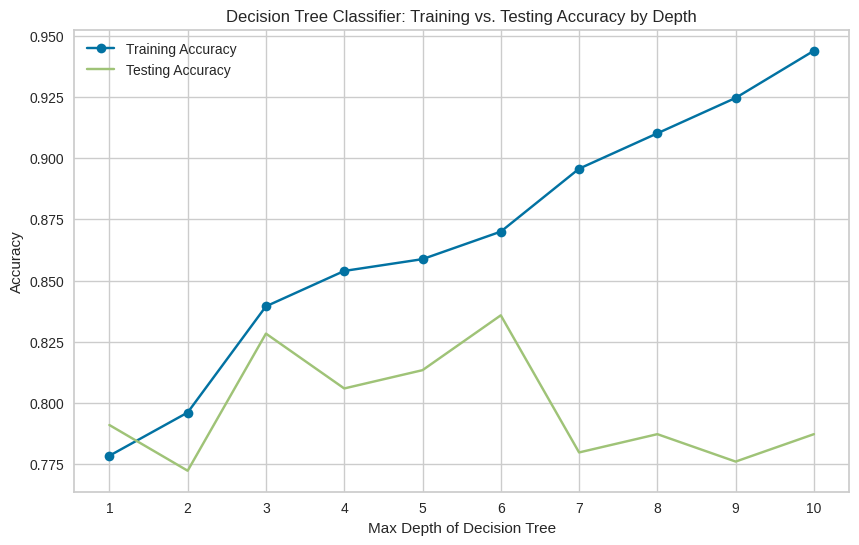

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), train_accuracies, marker='o', label='Training Accuracy')
plt.plot(range(1, 11), test_accuracies, marker='x', label='Testing Accuracy')
plt.title('Decision Tree Classifier: Training vs. Testing Accuracy by Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Accuracy')
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(tree_clf, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file

print("Decision tree image 'tree.png' has been generated.")

Decision tree image 'tree.png' has been generated.


## Explain: What is your understanding of the charts you made above?

**Ans:**

The chart displays the training and testing accuracies of the Decision Tree Classifier as the max_depth of the tree increases from 1 to 10.

*   **Training Accuracy:** We observe a consistent increase in training accuracy as the max_depth increases. This is expected because a deeper tree can learn more complex patterns and fit the training data more closely. At max_depth=10, the training accuracy is quite high, indicating the model is performing very well on the data it was trained on.

*   **Testing Accuracy:** The testing accuracy initially increases with max_depth (e.g., from depth 1 to 6), suggesting that deeper trees capture more relevant patterns. However, after a certain point (around max_depth=6), the testing accuracy starts to slightly decrease, even though the training accuracy continues to rise. For example, at max_depth=6, the testing accuracy is 0.835, which is quite good. But at max_depth=7, it drops to 0.779, and even at max_depth=10, it is 0.787.


# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [ ]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

y_pred_nb = naive_bayes.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(accuracy_nb)

0.6380597014925373


## Explain: What is the difference between Decision Tree Classifier and Naive Bayes algorithm?

**Ans:**

*   **Decision Tree Classifier:**
    *   **Approach:** Builds a tree-like model of decisions by splitting data based on feature values.
    *   **Feature Interaction:** Can model complex interactions between features.
    *   **Assumptions:** No strong assumptions about feature independence.
    *   **Overfitting:** Prone to overfitting with deep trees.

*   **Naive Bayes Algorithm:**
    *   **Approach:** Probabilistic classifier based on Bayes' theorem, assuming features are independent given the class.
    *   **Feature Interaction:** Assumes features are conditionally independent.
    *   **Assumptions:** Strong independence assumption.
    *   **Efficiency:** Computationally efficient, works well with sparse data.

## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#write code for random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(accuracy_rf)

0.7985074626865671


## Explain: Under what condition will Random Forest and Decision Trees have the same accuracy?

**Ans:**

Random Forests are an ensemble method that builds multiple Decision Trees and merges their predictions to improve accuracy and control overfitting.

There are specific conditions under which a Random Forest and a single Decision Tree might yield very similar, or even identical, accuracy:

1.  **Very Simple Dataset:**
    *   If the dataset is extremely simple, a single, well-tuned Decision Tree might be able to capture all the patterns with very few splits. In such a scenario, additional trees in a Random Forest might not add much value, as the problem is already solved by one tree.

2.  **Noisy Data or Irrelevant Features:**
    *   If there's a single, powerful feature that completely determines the target variable, both a Decision Tree and a Random Forest will quickly identify and utilize this feature.

3.  **Overly Pruned Decision Tree:**
    *   If the single Decision Tree is heavily pruned (e.g., max_depth=1), it might become so simplistic that its predictions are very stable but potentially biased. In some rare cases, if the Random Forest also produces very simple, highly correlated trees, their collective wisdom might not significantly exceed that of a single, simplified tree.

4.  **Small Number of Features:**
    *   In extremely small datasets or with a very limited number of features, the diversity among trees in a Random Forest might be constrained. This can sometimes lead to less benefit from ensembling.

## Extra - BaggingClassifier

In [ ]:
#write a code to implement BaggingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(random_state=42)
bagging = BaggingClassifier(estimator=base_estimator, n_estimators=100, random_state=42)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(accuracy_bagging)

0.7723880597014925


In [72]:
# Fine tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters found by GridSearchCV: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation score: 0.8378855444072834


In [74]:
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
print(accuracy_best_rf)

0.832089552238806


## Explain: What is the difference between Random Forest and Bagging Classifier

**Ans:**

Both Random Forest and Bagging Classifier are ensemble learning methods.

### Bagging Classifier

*   **Individual Models:** A Bagging Classifier trains multiple instances of the same base estimator (e.g., Decision Tree, Logistic Regression) on different subsets of the training data.
*   **Data Sampling:** It uses Bagging to create these subsets. This means it samples the training data with replacement for each base model. Each base model is trained on a different bootstrap sample.
*   **Feature Sampling:** Crucially, **Bagging does not involve feature sampling**. Each base model uses all available features for training.
*   **Primary Goal:** To reduce variance and prevent overfitting, especially when using complex base models like deep decision trees. By averaging or voting the predictions of multiple models trained on different data subsets, it smooths out the high variance of individual models.

### Random Forest

*   **Individual Models:** Random Forest is a specialized type of Bagging Classifier where the base estimator is always a Decision Tree. It builds an ensemble of decision trees.
*   **Data Sampling:** Like Bagging, it uses Bootstrap Aggregating to create different subsets of the training data for each decision tree.
*   **Feature Sampling:** This is the key differentiating factor. In addition to data sampling, Random Forest also employs feature sampling. At each split point in the decision tree building process, it considers only a random subset of features rather than all features. This introduces additional randomness and decorrelates the individual trees.
*   **Primary Goal:** To reduce both variance and the correlation between individual trees. By randomly selecting features for each split, it ensures that trees are diverse and don't all make decisions based on the same strong features. This makes the ensemble more robust and less prone to overfitting than a single decision tree or even a general Bagging Classifier with highly correlated base models.

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [75]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(random_state=42)

adaboost.fit(X_train, y_train)

y_pred_adaboost = adaboost.predict(X_test)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
print(accuracy_adaboost)

0.8134328358208955


## Explain: What is the difference between Bagging and Boosting

**Ans:**

Bagging and Boosting are both powerful ensemble learning techniques that combine multiple individual models to achieve better predictive performance than any single model alone.

### Bagging (e.g., Random Forest):

*   **Core Principle:** Bagging aims to reduce **variance** by training multiple models independently on different subsets of the training data. Each model is trained on a bootstrap sample (a random sample with replacement) of the original dataset. The final prediction is typically an average (for regression) or a majority vote (for classification) of the individual model predictions.

*   **How Models are Built:**
    *   **Parallel Learning:** Base learners (often Decision Trees) are trained in parallel. There is no dependency between the training of one model and another.
    *   **Data Sampling:** Each base learner is trained on a different bootstrap sample of the original data. This introduces randomness and diversity among the models.
    *   **Model Diversity:** High variance base models benefit most from bagging because the aggregation helps to average out their individual errors and reduce overfitting.

*   **Primary Goal:** To reduce variance and prevent overfitting, leading to more stable and robust predictions. It works best with models that have high variance and low bias.

### Boosting (e.g., AdaBoost, Gradient Boosting, XGBoost)

*   **Core Principle:** Boosting aims to reduce bias by sequentially building models, where each subsequent model tries to correct the errors of the previous ones. It focuses on misclassified instances by giving them more weight in subsequent training iterations.

*   **How Models are Built:**
    *   **Sequential Learning:** Base learners are trained sequentially. The training of a new model is dependent on the performance of the previous models.
    *   **Weighted Errors:** Instances that were misclassified by previous models are given higher weights so that the new model focuses more on learning from these difficult examples.
    *   **Model Aggregation:** The final prediction is a weighted sum of the individual model predictions, where models that pekrform better typically have higher weights.

*   **Primary Goal:** To reduce bias and convert a set of weak learners into a strong learner. It works best with models that have high bias and low variance.



```
# This is formatted as code
```

### 3. Pruning Techniques

https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107

In [ ]:
#write code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)


In [76]:
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01)

pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)

accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(accuracy_pruned)

0.8246268656716418


In [84]:
# Find the best alpha(plot graph)
tree_model = DecisionTreeClassifier(random_state=0)

path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    tree_pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
    tree_pruned.fit(X_train, y_train)
    train_scores.append(tree_pruned.score(X_train, y_train))
    test_scores.append(tree_pruned.score(X_test, y_test))

Best ccp_alpha: 0.006106660752346633
Highest Test Accuracy for this alpha: 0.8246268656716418


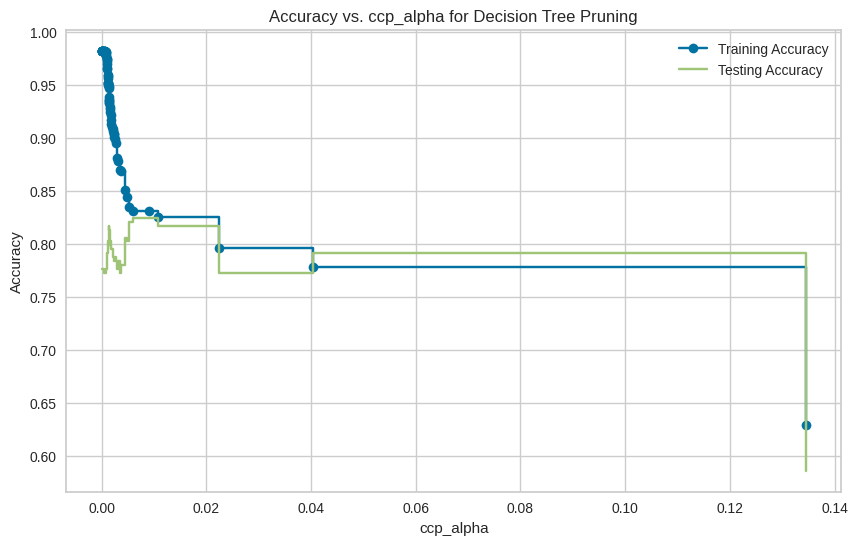

In [85]:
import numpy as np
import matplotlib.pyplot as plt

best_alpha_idx = np.argmax(test_scores)
best_ccp_alpha = ccp_alphas[best_alpha_idx]
best_test_accuracy = test_scores[best_alpha_idx]

print(f"Best ccp_alpha: {best_ccp_alpha}")
print(f"Highest Test Accuracy for this alpha: {best_test_accuracy}")

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Training Accuracy', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='x', label='Testing Accuracy', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. ccp_alpha for Decision Tree Pruning")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
from sklearn import tree

pruned_tree_viz = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
pruned_tree_viz.fit(X_train, y_train)

decision_tree_pruned = tree.export_graphviz(
    pruned_tree_viz,
    out_file='pruned_tree.dot',
    feature_names=X_train.columns,
    filled=True,
    max_depth=4
)

!dot -Tpng pruned_tree.dot -o pruned_tree.png

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

## Explain: After studying these techniques, analyse which method gives you the best accuracy and choose it as your most optimal model.

Ans:
Let's analyze the accuracy scores obtained from each of the implemented models:

*   **Decision Tree Classifier:** 0.7537
*   **Naive Bayes Classifier:** 0.6380
*   **Random Forest Classifier (Untuned):** 0.7985
*   **Bagging Classifier:** 0.7723
*   **Random Forest Classifier (GridSearchCV Tuned):** 0.8320
*   **AdaBoost Classifier:** 0.8134
*   **Pruned Decision Tree Classifier:** 0.8246

### Analysis:

Comparing the accuracies, the **Random Forest Classifier after hyperparameter tuning using GridSearchCV** yielded the highest accuracy of 0.8320 on the test set. Here's a brief breakdown:

1.  **Naive Bayes** performed the lowest, likely due to its strong assumption of feature independence, which might not hold true for our dataset.
2.  The **initial Decision Tree** had a decent performance but was susceptible to overfitting, as observed in the accuracy vs. depth chart.
3.  **Bagging Classifier** and **untuned Random Forest** showed improvement over the single Decision Tree.
4.  **AdaBoost Classifier**, a boosting technique, also showed good performance, surpassing the initial Decision Tree and Bagging.
5.  The **Pruned Decision Tree** significantly improved upon the initial Decision Tree, showing that controlling complexity with ccp_alpha effectively combats overfitting and improves generalization.
6.  The **tuned Random Forest Classifier** achieved the best score. This indicates that by optimizing hyperparameters such as n_estimators, max_depth, min_samples_split, and min_samples_leaf, the model was able to find a better balance between bias and variance, leading to superior performance on unseen data.

### Conclusion:

Based purely on the accuracy metric on the test set, the **Random Forest Classifier with hyperparameters tuned using GridSearchCV** (accuracy_best_rf = 0.8320) is the most optimal model among the ones tested.

# **Compulsory Task**

### **XGBoost and AdaBoost Classifier and Regressor: A Comparative Overview**

Both AdaBoost and XGBoost are powerful ensemble techniques under Boosting. They both aim to convert a set of 'weak' learners (typically decision trees) into a strong predictive model.

#### **AdaBoost (Adaptive Boosting)**

**Core Principle:** AdaBoost works sequentially by focusing on misclassified (or high-error) instances from previous weak learners. It adjusts the weights of the training data points in each iteration, giving more emphasis to those that were difficult to predict. The final prediction is a weighted sum of the weak learners predictions, where more accurate learners have higher weights.

**Mechanism:**
1.  **Initialization:** All training data points are assigned equal weights.
2.  **Iterative Learning:** In each iteration:
    *   A weak learner is trained on the currently weighted training data.
    *   The learner's error rate is calculated, and a weight is assigned to the learner based on its accuracy.
    *   The weights of the training data points are updated: misclassified points get increased weights, and correctly classified points get decreased weights.
3.  **Final Prediction:** The predictions of all weak learners are combined using their assigned weights.

**Characteristics:**
*   **Sequential:** Builds models one after another.
*   **Focus:** Corrects errors of previous learners.
*   **Sensitivity:** More sensitive to noisy data and outliers, as it tries to correct them.
*   **Performance:** Generally good, but can be less robust than gradient boosting methods on very complex datasets.

#### **XGBoost (Extreme Gradient Boosting)**

**Core Principle:** XGBoost is an optimized and highly efficient implementation of Gradient Boosting. Instead of re-weighting samples, Gradient Boosting builds weak learners sequentially, with each new tree attempting to predict the errors of the combined ensemble of previous trees. It uses a more sophisticated technique to minimize the loss function, incorporating regularization terms to prevent overfitting.

**Mechanism:**
1.  **Initialization:** Starts with an initial prediction (e.g., the mean of the target variable for regression, or log-odds for classification).
2.  **Iterative Learning:** In each iteration:
    *   A new weak learner (often a more complex decision tree than AdaBoost's stumps) is trained to predict the negative gradient of the loss function with respect to the current ensemble's predictions (i.e., to correct the errors).
    *   The new tree's prediction is added to the ensemble's current prediction, scaled by a learning rate.
    *   Regularization (L1 and L2) is applied to the tree structure and leaf weights to prevent overfitting.
3.  **Final Prediction:** Sums the predictions of all weak learners.

**Characteristics:**
*   **Sequential:** Builds models one after another.
*   **Focus:** Corrects residuals (errors) and minimizes a defined loss function.
*   **Robustness:** Highly robust and less prone to overfitting due to built-in regularization.